# From Bag-of-Words to Transformers: A Comparative Study of Text Classification Models : Practice & Experiments

The goal of this lab are to:
- Learn how to use Pytorch for treating textual data,
- Implementing neural classification models with Pytorch
    - Intialize them with pre-trained word embeddings and fine-tune them,
- Learn to import and fine-tune pre-trained models from Huggingface

Besides ```torch```, we will use ```transformers``` to obain the pre-trained model and fine-tune it.

In [1]:
import os.path as op
import re
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

## I - Simple classifier on top of dense representations

### I.1 Dataset

We're going to work with the **20NewsGroup** data. This dataset is available in ```scikit-learn```, we can find all relevant information in the [documentation](https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html).

In [2]:
from sklearn.datasets import fetch_20newsgroups

In [3]:
# Import training data
ng_train = fetch_20newsgroups(subset='train',
                              remove=('headers', 'footers', 'quotes')
                              )

In [4]:
# Let's look at what is in this object
pprint(dir(ng_train))

['DESCR', 'data', 'filenames', 'target', 'target_names']


In [5]:
# Let's look at the categories
pprint(ng_train.target_names)

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']


In [6]:
# .. and the data itself
pprint(ng_train.data[0])
print("Target: ", ng_train.target_names[ng_train.target[0]])

('I was wondering if anyone out there could enlighten me on this car I saw\n'
 'the other day. It was a 2-door sports car, looked to be from the late 60s/\n'
 'early 70s. It was called a Bricklin. The doors were really small. In '
 'addition,\n'
 'the front bumper was separate from the rest of the body. This is \n'
 'all I know. If anyone can tellme a model name, engine specs, years\n'
 'of production, where this car is made, history, or whatever info you\n'
 'have on this funky looking car, please e-mail.')
Target:  rec.autos


The dataset can be rather difficult as it is; especially, some categories are very close to each other. We can simplify the task by using the higher-level categorisation of the newsgroups, thanks to the following function:

In [7]:
def aggregate_labels(label):
    # comp
    if label in [1,2,3,4,5]:
        new_label = 0
    # rec
    if label in [7,8,9,10]:
        new_label = 1
    # sci
    if label in [11,12,13,14]:
        new_label = 2
    # misc
    if label in [6]:
        new_label = 3
    # pol
    if label in [16,17,18]:
        new_label = 4
    # rel
    if label in [0,15,19]:
        new_label = 5
    return new_label

We will first need to apply some pre-processing:
- The data is represented as a string: ```'I love this movie'```
- We want to obtain a list of **tokens**, which are instances of words: ```['I','love','this','movie']```

This is called **tokenization**. We will import an existing tokenizer and use it on each document to obtain a list of words. Careful, the data is not always clean and the messages are sometimes short: hence, applying tokenization can sometimes return an empty list of words. **Be careful to remove documents that are empty !**
<div class='alert alert-block alert-info'>
            Code:</div>

In [8]:
import nltk
# A little data necessary for the first time we use word_tokenize - uncomment
nltk.download('punkt_tab')
from nltk import word_tokenize

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\alexa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [9]:
pprint(word_tokenize(ng_train.data[0]))

['I',
 'was',
 'wondering',
 'if',
 'anyone',
 'out',
 'there',
 'could',
 'enlighten',
 'me',
 'on',
 'this',
 'car',
 'I',
 'saw',
 'the',
 'other',
 'day',
 '.',
 'It',
 'was',
 'a',
 '2-door',
 'sports',
 'car',
 ',',
 'looked',
 'to',
 'be',
 'from',
 'the',
 'late',
 '60s/',
 'early',
 '70s',
 '.',
 'It',
 'was',
 'called',
 'a',
 'Bricklin',
 '.',
 'The',
 'doors',
 'were',
 'really',
 'small',
 '.',
 'In',
 'addition',
 ',',
 'the',
 'front',
 'bumper',
 'was',
 'separate',
 'from',
 'the',
 'rest',
 'of',
 'the',
 'body',
 '.',
 'This',
 'is',
 'all',
 'I',
 'know',
 '.',
 'If',
 'anyone',
 'can',
 'tellme',
 'a',
 'model',
 'name',
 ',',
 'engine',
 'specs',
 ',',
 'years',
 'of',
 'production',
 ',',
 'where',
 'this',
 'car',
 'is',
 'made',
 ',',
 'history',
 ',',
 'or',
 'whatever',
 'info',
 'you',
 'have',
 'on',
 'this',
 'funky',
 'looking',
 'car',
 ',',
 'please',
 'e-mail',
 '.']


In [10]:
# Pre-processing
ng_train_text = []
ng_train_labels = []

for text, label in zip(ng_train.data, ng_train.target):
    tokens = word_tokenize(text)
    if len(tokens) > 0:
        ng_train_text.append(tokens)
        ng_train_labels.append(aggregate_labels(label))

In [11]:
ng_test = fetch_20newsgroups(subset='test',
                             remove=('headers', 'footers', 'quotes')
                            )

ng_test_text = []
ng_test_labels = []

for text, label in zip(ng_test.data, ng_test.target):
    tokens = word_tokenize(text)
    if len(tokens) > 0:
        ng_test_text.append(tokens)
        ng_test_labels.append(aggregate_labels(label))

### I.2 Get a vocabulary.

Now that the data is tokenized, the first step we will follow is to pick a **common vocabulary** that we will use for every model we create in this lab.

It would be too costly to ask our model to represent every word. We will have to be able to control its size, either by indicating a **maximum number of words**. **We add, at the end, an "unknown" word that will replace all the words that do not appear in our "limited" vocabulary**.

<div class='alert alert-block alert-info'>
            Code:</div>

In [12]:
def vocabulary(corpus, voc_threshold=None):
    """
    Function using word counts to build a vocabulary - can be improved with a second parameter for
    setting a frequency threshold
    Params:
        corpus (list of list of tokens): corpus of sentences already tokenized
        voc_threshold (int): maximum size of the vocabulary. Use "0" to indicate no limit
    Returns:
        vocabulary (dictionary): keys: list of distinct words across the corpus
                                 values: indexes corresponding to each word sorted by frequency
        vocabulary_word_counts (dictionary): keys: list of distinct words across the corpus
                                             values: corresponding counts of words in the corpus
    """

    word_counts = {}
    for sent in corpus:
        # To complete: count word frequencies
        for word in sent:
            word_counts[word] = word_counts.get(word, 0) + 1

    sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)  # Extract the words according to frequency

    if voc_threshold is None or voc_threshold == 0:
        filtered_words = [word for word, count in sorted_words]  # Remove the words above voc-threshold
    else:
        filtered_words = [word for word, count in sorted_words[:voc_threshold]]  # Remove the words above voc-threshold

    words = filtered_words + ["UNK"]  # Add UNK
    vocabulary = {word: idx for idx, word in enumerate(words)}  # Create vocabulary from "words"

    return vocabulary, {word: word_counts.get(word, 0) for word in vocabulary}

In [ ]:
# Example for testing:

corpus = ['I walked down down the boulevard',
          'I walked down the avenue',
          'I ran down the boulevard',
          'I walk down the city',
          'I walk down the the avenue']
corpus = [word_tokenize(sent) for sent in corpus]

voc, counts = vocabulary(corpus, voc_threshold = 3)
print(voc)
print(counts)

# We expect something like this:
# (In this example, we don't count 'UNK' unknown words, but we can if we want to. 
# How useful it may be depends on the data -> we will use the counts later with word2vec, keep that in mind) 
#  {'down': 0, 'the': 1, 'i': 2, 'UNK': 3}
#  {'down': 6, 'the': 6, 'i': 5, 'UNK': 0}

voc, counts = vocabulary(corpus)
print(voc)
print(counts)

# We expect something like this:
#  {'down': 0, 'the': 1, 'i': 2, 'walked': 3, 'boulevard': 4, 'avenue': 5, 'walk': 6, 'ran': 7, 'city': 8, 'UNK': 9}
#  {'down': 6, 'the': 6, 'i': 5, 'walked': 2, 'boulevard': 2, 'avenue': 2, 'walk': 2, 'ran': 1, 'city': 1, 'UNK': 0}

{'down': 0, 'the': 1, 'I': 2, 'UNK': 3}
{'down': 6, 'the': 6, 'I': 5, 'UNK': 0}
{'down': 0, 'the': 1, 'I': 2, 'walked': 3, 'boulevard': 4, 'avenue': 5, 'walk': 6, 'ran': 7, 'city': 8, 'UNK': 9}
{'down': 6, 'the': 6, 'I': 5, 'walked': 2, 'boulevard': 2, 'avenue': 2, 'walk': 2, 'ran': 1, 'city': 1, 'UNK': 0}


Before creating the final vocabulary to be used, put aside some training data for a **validation set** !

<div class='alert alert-block alert-info'>
            Code:</div>

In [14]:
from sklearn.model_selection import train_test_split
train_texts_splt, val_texts, train_labels_splt, val_labels = train_test_split(ng_train_text, ng_train_labels, test_size=.2)

In [15]:
# Get the vocabulary from 'train_texts_splt'
# With threshold !
vocab_cut, word_counts_cut = vocabulary(train_texts_splt, voc_threshold=10000)

### I.3 Getting a representation: commonly used algorithms with ```gensim```

The idea here is to define a set of representations $({w_{i}})_{i=1}^{V}$, of predefined dimension $d$ (here, we will work with $d = 300$), for all the words $i$ of the vocabulary $V$ - then **train** these representations to match what we want.

#### Glove

The objective defined by Glove ([Pennington et al. (2014)](http://www.aclweb.org/anthology/D/D14/D14-1162.pdf)) is to learn from the vectors $w_{i}$ and $w_{k}$ so that their scalar product corresponds to the logarithm of their **Pointwise Mutual Information**:


$$ w_{i}^\top w_{k} = (PMI(w_{i}, w_{k}))$$


In the article, this objective is carefully justified by a reasoning about the operations one wants to perform with these vectors and the properties they should have - in particular, symmetry between rows and columns (see the article for more details).  
The final goal obtained is the following, where $M$ is the co-occurrence matrix:


$$\sum_{i, j=1}^{|V|} f\left(M_{ij}\right)
  \left(w_i^\top w_j + b_i + b_j - \log M_{ij}\right)^2$$
  

Here, $f$ is a *scaling* function that reduces the importance of the most frequent co-occurrence counts:


$$f(x)
\begin{cases}
(x/x_{\max})^{\alpha} & \textrm{if } x < x_{\max} \\
1 & \textrm{otherwise}
\end{cases}$$


Usually, we choose $\alpha=0.75$ and $x_{\max} = 100$, although these parameters may need to be changed depending on the data. The following code uses the ```gensim``` API to retrieve pre-trained representations (word embeddings take space - a long loading time is expected).

In [16]:
import gensim.downloader as api
loaded_glove_model = api.load("glove-wiki-gigaword-300")

We can extract the embedding matrix this way, and check its size:

In [17]:
import gensim
print(gensim.__version__)
print(np.__version__)

4.4.0
2.4.3


In [18]:
loaded_glove_embeddings = loaded_glove_model.vectors
print(loaded_glove_embeddings.shape)

(400000, 300)


We can see that there are $400,000$ words represented, and that the embeddings are of size $300$. We define a function that returns, from the loaded model, the vocabulary and the embedding matrix according to the structures we used before. We add, here again, an unknown word "UNK" in case there are words in our data that are not part of the $400,000$ words represented here.

In [19]:
def get_glove_voc_and_embeddings(glove_model):
    voc = {word : index for word, index in enumerate(glove_model.index_to_key)}
    voc['UNK'] = len(voc)
    embeddings = glove_model.vectors
    return voc, embeddings

In [20]:
loaded_glove_voc, loaded_glove_embeddings = get_glove_voc_and_embeddings(loaded_glove_model)

To be able to merge these $400.000$ words with those that are in our vocabulary, we can create a specific function that will extract the representations of the words that are in our vocabulary and return a matrix of the appropriate size:

In [21]:
def get_glove_adapted_embeddings(glove_model, input_voc):
    keys = {i: glove_model.key_to_index.get(w, None) for w, i in input_voc.items()}
    index_dict = {i: key for i, key in keys.items() if key is not None}
    embeddings = np.zeros((len(input_voc),glove_model.vectors.shape[1]))
    for i, ind in index_dict.items():
        embeddings[i] = glove_model.vectors[ind]
    return embeddings

This function takes as input the model loaded using the Gensim API, as well as a vocabulary we created ourselves, and returns the embedding matrix from the loaded model, for the words in our vocabulary and in the right order.


In [22]:
GloveEmbeddings = get_glove_adapted_embeddings(loaded_glove_model, vocab_cut)

In [23]:
print(GloveEmbeddings.shape)

(10001, 300)


# II - Text classification with Pytorch

The goal of this second part of the lab is double: an introduction to using Pytorch for treating textual data, and implementing neural classification models that we can apply to 20Newsgroup data - and then compare it to the models implemented previously.

In [24]:
import torch
import torch.nn as nn

### II.1 A (very small) introduction to pytorch

Pytorch Tensors are very similar to Numpy arrays, with the added benefit of being usable on GPU. For a short tutorial on various methods to create tensors of particular types, see [this link](https://pytorch.org/tutorials/beginner/blitz/tensor_tutorial.html#sphx-glr-beginner-blitz-tensor-tutorial-py).
The important things to note are that Tensors can be created empty, from lists, and it is very easy to convert a numpy array into a pytorch tensor, and inversely.

In [25]:
a = torch.LongTensor(5)
b = torch.LongTensor([5])

print(a)
print(b)

tensor([0, 0, 0, 0, 0])
tensor([5])


In [26]:
a = torch.FloatTensor([2])
b = torch.FloatTensor([3])

print(a + b)

tensor([5.])


The main interest in us using Pytorch is the ```autograd``` package. ```torch.Tensor```objects have an attribute ```.requires_grad```; if set as True, it starts to track all operations on it. When we finish our computation, can call ```.backward()``` and all the gradients are computed automatically (and stored in the ```.grad``` attribute).

One way to easily cut a tensor from the computational once it is not needed anymore is to use ```.detach()```.
More info on automatic differentiation in pytorch on [this link](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html#sphx-glr-beginner-blitz-autograd-tutorial-py).

In [27]:
x = torch.tensor(1., requires_grad=True)
w = torch.tensor(2., requires_grad=True)
b = torch.tensor(3., requires_grad=True)

# Build a computational graph.
y = w * x + b    # y = 2 * x + 3

# Compute gradients.
y.backward()

# Print out the gradients.
print(x.grad)    # x.grad = 2
print(w.grad)    # w.grad = 1
print(b.grad)    # b.grad = 1

tensor(2.)
tensor(1.)
tensor(1.)


In [28]:
x = torch.randn(10, 3)
y = torch.randn(10, 2)

# Build a fully connected layer.
linear = nn.Linear(3, 2)
for name, p in linear.named_parameters():
    print(name)
    print(p)

# Build loss function - Mean Square Error
criterion = nn.MSELoss()

# Forward pass.
pred = linear(x)

# Compute loss.
loss = criterion(pred, y)
print('Initial loss: ', loss.item())

# Backward pass.
loss.backward()

# Print out the gradients.
print ('dL/dw: ', linear.weight.grad)
print ('dL/db: ', linear.bias.grad)

weight
Parameter containing:
tensor([[ 0.1544, -0.0816,  0.2922],
        [-0.0427, -0.0990, -0.4459]], requires_grad=True)
bias
Parameter containing:
tensor([-0.0752,  0.0732], requires_grad=True)
Initial loss:  1.1751257181167603
dL/dw:  tensor([[ 0.3197, -0.4336, -0.2690],
        [ 0.0366, -0.1659, -0.0902]])
dL/db:  tensor([-0.8414, -0.0936])


In [ ]:
# We can perform gradient descent manually, with an in-place update ...
linear.weight.data.sub_(0.01 * linear.weight.grad.data)
linear.bias.data.sub_(0.01 * linear.bias.grad.data)

# Print out the loss after 1-step gradient descent.
pred = linear(x)
loss = criterion(pred, y)
print('Loss after one update: ', loss.item())

Loss after one update:  1.164017677307129


In [30]:
# Use the optim package to define an Optimizer that will update the weights of the model.
optimizer = torch.optim.SGD(linear.parameters(), lr=0.01)

# By default, gradients are accumulated in buffers( i.e, not overwritten) whenever .backward()
# is called. Before the backward pass, we need to use the optimizer object to zero all of the
# gradients.
optimizer.zero_grad()
loss.backward()

# Calling the step function on an Optimizer makes an update to its parameters
optimizer.step()

# Print out the loss after the second step of gradient descent.
pred = linear(x)
loss = criterion(pred, y)
print('Loss after two updates: ', loss.item())

Loss after two updates:  1.1531260013580322


### II.2 Tools for data processing

```torch.utils.data.Dataset``` is an abstract class representing a dataset. Our custom dataset should inherit ```Dataset``` and override the following methods:
- ```__len__``` so that ```len(dataset)``` returns the size of the dataset.
- ```__getitem__``` to support the indexing such that ```dataset[i]``` can be used to get the i-th sample

Here is a toy example:

In [31]:
toy_corpus = ['I walked down down the boulevard',
              'I walked down the avenue',
              'I ran down the boulevard',
              'I walk down the city',
              'I walk down the the avenue']

toy_categories = [0, 0, 1, 0, 0]

In [32]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    # A pytorch dataset class for holding data for a text classification task.
    def __init__(self, data, categories):
        # Upon creating the Dataset object, store the data in an attribute
        # Split the text data and labels from each other
        self.X, self.Y = [], []
        for x, y in zip(data, categories):
            # We will propably need to preprocess the data - have it done in a separate method
            # We do it here because we might need corpus-wide info to do the preprocessing
            # For example, cutting all examples to the same length
            self.X.append(self.preprocess(x))
            self.Y.append(y)

    # Method allowing you to preprocess data
    def preprocess(self, text):
        text_pp = text.lower().strip()
        return text_pp

    # Overriding the method __len__ so that len(CustomDatasetName) returns the number of data samples
    def __len__(self):
        return len(self.Y)

    # Overriding the method __getitem__ so that CustomDatasetName[i] returns the i-th sample of the dataset
    def __getitem__(self, idx):
           return self.X[idx], self.Y[idx]

In [33]:
toy_dataset = CustomDataset(toy_corpus, toy_categories)

In [34]:
print(len(toy_dataset))
for i in range(len(toy_dataset)):
    print(toy_dataset[i])

5
('i walked down down the boulevard', 0)
('i walked down the avenue', 0)
('i ran down the boulevard', 1)
('i walk down the city', 0)
('i walk down the the avenue', 0)


```torch.utils.data.DataLoader``` is what we call an iterator, which provides very useful features:
- Batching the data
- Shuffling the data
- Load the data in parallel using multiprocessing workers.
and can be created very simply from a ```Dataset```. Continuing on our simple example:

In [35]:
toy_dataloader = DataLoader(toy_dataset, batch_size = 2, shuffle = True)

In [36]:
for e in range(3):
    print("Epoch:" + str(e))
    for x, y in toy_dataloader:
        print("Batch: " + str(x) + "; labels: " + str(y))

Epoch:0
Batch: ('i walked down down the boulevard', 'i walk down the city'); labels: tensor([0, 0])
Batch: ('i ran down the boulevard', 'i walked down the avenue'); labels: tensor([1, 0])
Batch: ('i walk down the the avenue',); labels: tensor([0])
Epoch:1
Batch: ('i walk down the the avenue', 'i ran down the boulevard'); labels: tensor([0, 1])
Batch: ('i walked down the avenue', 'i walked down down the boulevard'); labels: tensor([0, 0])
Batch: ('i walk down the city',); labels: tensor([0])
Epoch:2
Batch: ('i ran down the boulevard', 'i walked down the avenue'); labels: tensor([1, 0])
Batch: ('i walk down the the avenue', 'i walked down down the boulevard'); labels: tensor([0, 0])
Batch: ('i walk down the city',); labels: tensor([0])


#### Data processing of a text dataset

Now, we would like to apply what we saw to our case, and **create a specific class** ```TextClassificationDataset``` **inheriting** ```Dataset``` that will:
- Create a vocabulary from the data (same as above)
- Preprocess the data using this vocabulary, adding whatever we need for our pytorch model
- Have a ```__getitem__``` method that allows us to use the class with a ```Dataloader``` to easily build batches.

In [37]:
from torch.nn import functional as F
import random

from torch.nn.utils.rnn import pad_sequence

We will now need to create a ```TextClassificationDataset``` and a ```Dataloader``` for the training data, the validation data, and the testing data.

We will implement our ```TextClassificationDataset``` class, that we will build from:
- A list of documents: ```data```
- A list of the corresponding categories: ```categories```
We will add three optional arguments:
- First, a way to input a vocabulary (so that we can re-use the training vocabulary on the validation and training ```TextClassificationDataset```). By default, the value of the argument is ```None```.
- In order to work with batches, we will need to have sequences of the same size. That can be done via **padding** but we will still need to limit the size of documents (to avoid having batches of huge sequences that are mostly empty because of one very long documents) to a ```max_length```. Let's put it to 100 by default.
- Lastly, a ```min_freq``` that indicates how many times a word must appear to be taken in the vocabulary.

The idea behind **padding** is to transform a list of pytorch tensors (of maybe different length) into a two dimensional tensor - which we can see as a batch. The size of the first dimension is the one of the longest tensor - and other are **padded** with a chosen symbol: here, we choose 0.

**Careful: the symbol 0 is then reserved for padding. That means the vocabulary must begin at 1 !**

In [38]:
tensor_1 = torch.LongTensor([1, 4, 5])
tensor_2 = torch.LongTensor([2])
tensor_3 = torch.LongTensor([6, 7])

In [39]:
tensor_padded = pad_sequence([tensor_1, tensor_2, tensor_3], batch_first=True, padding_value = 0)
print(tensor_padded)

tensor([[1, 4, 5],
        [2, 0, 0],
        [6, 7, 0]])


<div class='alert alert-block alert-info'>
            Code:</div>

In [40]:
class TextClassificationDataset(Dataset):
    def __init__(self, data, categories, vocab = None, max_length = 200, voc_threshold = 10000):
        # Get all the data in a list
        self.data = data
        # Set the maximum length we will keep for the sequences
        self.max_length = max_length
        # Allow to import a vocabulary (for valid/test datasets, that will use the training vocabulary)
        if vocab is not None:
            self.word2idx, self.idx2word = vocab
        else:
            # If no vocabulary imported, build it (and reverse)
            self.word2idx, self.idx2word = self.build_vocab(self.data, voc_threshold)
        
        # Transform list of words into lists of indexes ... (use the .get() method to redirect unknown words to the UNK token)
        indexed_data = [[self.word2idx.get(word, self.word2idx["UNK"]) for word in sent] for sent in self.data]
        # And transform this list of lists into a list of Pytorch LongTensors
        tensor_data = [torch.LongTensor(sent) for sent in indexed_data]
        # And the categories into a FloatTensor
        tensor_y = torch.FloatTensor(categories)
        # To finally cut it when it's above the maximum length
        cut_tensor_data = [sent[:self.max_length] for sent in tensor_data]
        
        # Now, we need to use the pad_sequence function to have the whole dataset represented as one tensor,
        # containing sequences of the same length. We choose the padding_value to be 0, the we want the
        # batch dimension to be the first dimension 
        self.tensor_data = pad_sequence(cut_tensor_data, batch_first=True, padding_value=0)
        self.tensor_y = tensor_y
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # The iterator just gets one particular example with its category
        # The dataloader will take care of the shuffling and batching
        if torch.is_tensor(idx):
            idx = idx.tolist()
        return self.tensor_data[idx], self.tensor_y[idx] 
    
    def build_vocab(self, corpus, voc_threshold):
        """
        Same as in the previously: we want to output word_index, a dictionary containing words 
        and their corresponding indexes as {word : indexes} 
        But we also want the reverse, which is a dictionary {indexes: word}
        """
        # To complete
        # Careful, here we need to shift the indexes by 1 to put the padding symbol to 0
        word2idx_raw, _ = vocabulary(corpus, voc_threshold)
        word2idx = {word: idx + 1 for word, idx in word2idx_raw.items()}
        idx2word = {idx: word for word, idx in word2idx.items()}
        return word2idx, idx2word
    
    def get_vocab(self):
        # A simple way to get the training vocab when building the valid/test 
        return self.word2idx, self.idx2word

In [41]:
training_dataset = TextClassificationDataset(train_texts_splt, train_labels_splt)
training_word2idx, training_idx2word = training_dataset.get_vocab()

In [42]:
valid_dataset = TextClassificationDataset(val_texts, val_labels, (training_word2idx, training_idx2word))
test_dataset = TextClassificationDataset(ng_test_text, ng_test_labels, (training_word2idx, training_idx2word))

In [43]:
training_dataloader = DataLoader(training_dataset, batch_size = 200, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size = 25)
test_dataloader = DataLoader(test_dataset, batch_size = 25)

In [44]:
print(valid_dataset[1])

(tensor([  130,   236,    42,    30,  1040,    26,    13,     9,   150,     8,
           66,  8520,    31,    34,   974,    84,   395, 10001,    53,  2556,
            1,    15,   265,     1,  2556,  1171,     7,    31,  2679,   166,
           62,    34,    63,     8,    66,   997,   466,     9, 10001,     1,
           85,   213,    25,   427,  8133,    56,    76,    47,  2556,     1,
          230, 10001,    69,  5740,  1824,  1594,  2556,     9,     3,    93,
           26,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,

In [45]:
example_batch = next(iter(training_dataloader))
print(example_batch[0].size())
print(example_batch[1].size())

torch.Size([200, 200])
torch.Size([200])


### II.3 A simple averaging model

Now, we will implement in Pytorch what we did in the previous TP: a simple averaging model. For each model we will implement, we need to create a class which inherits from ```nn.Module``` and redifine the ```__init__``` method as well as the ```forward``` method.

In [46]:
import torch.optim as optim

<div class='alert alert-block alert-info'>
            Code:</div>

In [ ]:
class AveragingModel(nn.Module):
    
    def __init__(self, embedding_dim, vocabulary_size, categories_num):
        super().__init__()
        # Create an embedding object. Be careful to padding - We need to increase the vocabulary size by one !
        # Look into the arguments of the nn.Embedding class
        self.embeddings = nn.Embedding(vocabulary_size + 1, embedding_dim, padding_idx=0)
        # Create a linear layer that will transform the mean of the embeddings into classification scores
        self.linear = nn.Linear(embedding_dim, categories_num)
    
    def forward(self, inputs):
        # Remember: the inputs are written as Batch_size * seq_length * embedding_dim
        # First, take the mean of the embeddings of the document
        x = self.embeddings(inputs)
        x = x.mean(dim=1)
        o = self.linear(x)
        return o

In [48]:
model = AveragingModel(300, len(training_word2idx), max(ng_train_labels)+1)
# Create an optimizer
opt = optim.Adam(model.parameters(), lr=0.0025, betas=(0.9, 0.999))
# The criterion is a cross entropy loss based on logits,
# meaning that the softmax is integrated into the criterion
criterion = nn.CrossEntropyLoss()

<div class='alert alert-block alert-info'>
            Code:</div>

In [ ]:
# Implement a training function, which will train the model with the corresponding optimizer and criterion,
# with the appropriate dataloader, for one epoch.

def train_epoch(model, opt, criterion, dataloader):
    model.train()
    losses = []
    for i, (x, y) in enumerate(dataloader):
        opt.zero_grad()
        # (1) Forward
        pred = model(x)
        # (2) Compute diff
        loss = criterion(pred, y.long())
        # (3) Compute gradients
        loss.backward()
        # (4) update weights
        opt.step()
        losses.append(loss.item())
        # Count the number of correct predictions in the batch - here, we'll need to use the softmax
        num_corrects = (F.softmax(pred, dim=1).argmax(dim=1) == y.long()).sum()
        acc = 100.0 * num_corrects / len(y)

        if (i % 20 == 0):
            print("Batch " + str(i) + " : training loss = " + str(loss.item()) + "; training acc = " + str(acc.item()))
    return losses

<div class='alert alert-block alert-info'>
            Code:</div>

In [50]:
# Same for the evaluation ! We don't need the optimizer here.

def eval_model(model, criterion, evalloader):
    model.eval()
    total_epoch_loss = 0
    total_epoch_acc = 0
    with torch.no_grad():
        for i, (x, y) in enumerate(evalloader):
            pred = model(x)
            loss = criterion(pred, y.long())
            num_corrects = (F.softmax(pred, dim=1).argmax(dim=1) == y.long()).sum()
            acc = 100.0 * num_corrects / len(y)
            total_epoch_loss += loss.item()
            total_epoch_acc += acc.item()

    return total_epoch_loss/(i+1), total_epoch_acc/(i+1)

In [ ]:
# A function which will help we execute experiments rapidly - with a early_stopping option when necessary.

def experiment(model, opt, criterion, num_epochs = 10, early_stopping = True):
    train_losses = []
    if early_stopping:
        best_valid_loss = 10.
    print("Beginning training...")
    for e in range(num_epochs):
        print("Epoch " + str(e+1) + ":")
        train_losses += train_epoch(model, opt, criterion, training_dataloader)
        valid_loss, valid_acc = eval_model(model, criterion, valid_dataloader)
        print("Epoch " + str(e+1) + " : Validation loss = " + str(valid_loss) + "; Validation acc = " + str(valid_acc))
        if early_stopping:
            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
            else:
                print("Early stopping.")
                break
    test_loss, test_acc = eval_model(model, criterion, test_dataloader)
    print("Epoch " + str(e+1) + " : Test loss = " + str(test_loss) + "; Test acc = " + str(test_acc))
    return train_losses

In [52]:
train_losses = experiment(model, opt, criterion)

Beginning training...
Epoch 1:
Batch 0 : training loss = 1.8084133863449097; training acc = 11.5
Batch 20 : training loss = 1.663356900215149; training acc = 36.5
Batch 40 : training loss = 1.5941712856292725; training acc = 43.5
Epoch 1 : Validation loss = 1.5861284813184418; Validation acc = 47.67041195644421
Epoch 2:
Batch 0 : training loss = 1.5482707023620605; training acc = 52.0
Batch 20 : training loss = 1.5328376293182373; training acc = 46.5
Batch 40 : training loss = 1.4568076133728027; training acc = 55.0
Epoch 2 : Validation loss = 1.378569032369035; Validation acc = 57.2883894845341
Epoch 3:
Batch 0 : training loss = 1.346855878829956; training acc = 60.5
Batch 20 : training loss = 1.2079627513885498; training acc = 64.0
Batch 40 : training loss = 1.1876444816589355; training acc = 64.5
Epoch 3 : Validation loss = 1.1844218339812889; Validation acc = 62.636704091275675
Epoch 4:
Batch 0 : training loss = 1.1044337749481201; training acc = 66.0
Batch 20 : training loss = 1.1

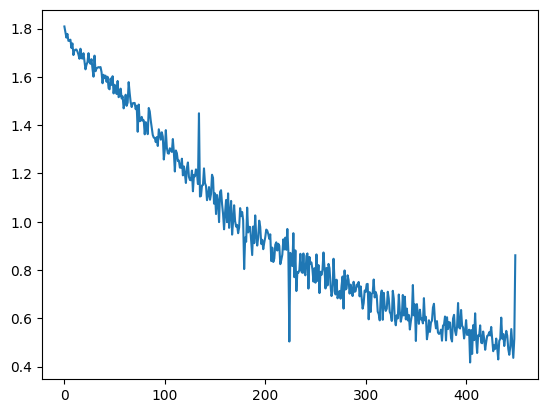

In [53]:
import matplotlib.pyplot as plt
plt.plot(train_losses)

### II.4 Initializing with pre-trained embeddings:

Now, we would like to integrate pre-trained word embeddings into our model ! However, we need to not forget to add a vector for the padding symbol.

In [54]:
def get_glove_adapted_embeddings(glove_model, input_voc):
    keys = {i: glove_model.key_to_index.get(w, None) for w, i in input_voc.items()}
    index_dict = {i: key for i, key in keys.items() if key is not None}
    # Important change here: add one supplementary word for padding
    embeddings = np.zeros((len(input_voc)+1,glove_model.vectors.shape[1]))
    for i, ind in index_dict.items():
        embeddings[i] = glove_model.vectors[ind]
    return embeddings

GloveEmbeddings = get_glove_adapted_embeddings(loaded_glove_model, training_word2idx)

In [55]:
print(GloveEmbeddings.shape)

(10002, 300)


Here, implement a ```PretrainedAveragingModel``` very similar to the previous model, using the ```nn.Embedding``` method ```from_pretrained()``` to initialize the embeddings from a numpy array. Use the ```requires_grad_``` method to specify if the model must fine-tune the embeddings or not !
<div class='alert alert-block alert-info'>
            Code:</div>

In [56]:
class PretrainedAveragingModel(nn.Module):
    
    def __init__(self, embedding_matrix, categories_num, freeze_embeddings=False):
        super().__init__()
        
        # Create embedding layer from pretrained weights
        self.embeddings = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix),
            padding_idx=0
        )
        
        # Freeze or not the embeddings
        self.embeddings.weight.requires_grad = not freeze_embeddings
        
        # Linear classifier
        embedding_dim = embedding_matrix.shape[1]
        self.linear = nn.Linear(embedding_dim, categories_num)
    
    def forward(self, inputs):
        x = self.embeddings(inputs)          # (batch, seq_len, emb_dim)
        x = x.mean(dim=1)                   # (batch, emb_dim)
        o = self.linear(x)                  # (batch, num_classes)
        return o

<div class='alert alert-block alert-warning'>
            Questions:</div>
            
- What are the results **with and without fine-tuning of embeddings imported from GloVe** ? Explain them.
- Use the following ```sklearn``` functions: ```confusion_matrix, ConfusionMatrixDisplay, classification_report``` from (```sklearn.metrics```) to analyze the results further.  

## Results Analysis

Using pre-trained GloVe embeddings without fine-tuning provides a strong initial representation of words. The model benefits from semantic structure learned on large corpora, which leads to faster convergence and generally good generalization. However, these embeddings remain fixed and cannot adapt to the specific characteristics of the dataset, which may limit performance on domain-specific patterns.

When fine-tuning is enabled, the embeddings are updated during training. This allows the model to better capture dataset-specific information and often improves performance, especially on the training set. However, this flexibility comes with a trade-off: the model may overfit and lose part of the general semantic structure learned from GloVe if the data is limited or if training is not well controlled.

To analyze the results more thoroughly, accuracy alone is not sufficient. A confusion matrix helps identify which classes are correctly predicted and which are frequently confused. This gives insight into similarities between categories and potential weaknesses of the model. The classification report complements this by providing precision, recall, and F1-score for each class, allowing a more detailed evaluation of performance across categories.

These tools provide a clearer understanding of the model’s behavior and highlight whether improvements from fine-tuning are consistent across all classes or limited to specific cases.

In [57]:
model_pre_trained = PretrainedAveragingModel(
    GloveEmbeddings,
    len(training_word2idx),
    freeze_embeddings=True
)
opt_pre_trained = optim.Adam(model_pre_trained.parameters(), lr=0.0025, betas=(0.9, 0.999))

In [58]:
train_losses = experiment(model_pre_trained, opt_pre_trained, criterion)

Beginning training...
Epoch 1:
Batch 0 : training loss = 9.198720932006836; training acc = 0.0
Batch 20 : training loss = 7.805047988891602; training acc = 13.0
Batch 40 : training loss = 6.501684665679932; training acc = 19.5
Epoch 1 : Validation loss = 6.078415018788884; Validation acc = 21.093632944514244
Epoch 2:
Batch 0 : training loss = 5.903573513031006; training acc = 17.0
Batch 20 : training loss = 4.901690483093262; training acc = 26.0
Batch 40 : training loss = 4.497453689575195; training acc = 22.0
Epoch 2 : Validation loss = 4.321502197994275; Validation acc = 23.655430697323233
Epoch 3:
Batch 0 : training loss = 4.175024032592773; training acc = 28.5
Batch 20 : training loss = 3.8736886978149414; training acc = 30.5
Batch 40 : training loss = 3.763685941696167; training acc = 36.5
Epoch 3 : Validation loss = 3.7100495970651006; Validation acc = 38.00749060812961
Epoch 4:
Batch 0 : training loss = 3.428201198577881; training acc = 40.0
Batch 20 : training loss = 3.51866245

In [59]:
model_pre_trained_light = PretrainedAveragingModel(
    GloveEmbeddings,
    max(ng_train_labels)+1,
    False
)

opt_pre_trained_light = optim.Adam(
    model_pre_trained_light.parameters(),
    lr=0.0025,
    betas=(0.9, 0.999)
)

In [60]:
train_losses = experiment(model_pre_trained_light, opt_pre_trained_light, criterion)

Beginning training...
Epoch 1:
Batch 0 : training loss = 1.7962230443954468; training acc = 14.0
Batch 20 : training loss = 1.6674199104309082; training acc = 29.0
Batch 40 : training loss = 1.5928272008895874; training acc = 50.0
Epoch 1 : Validation loss = 1.5599233300498363; Validation acc = 53.138576764738964
Epoch 2:
Batch 0 : training loss = 1.5591130256652832; training acc = 47.5
Batch 20 : training loss = 1.5014398097991943; training acc = 57.0
Batch 40 : training loss = 1.2611027956008911; training acc = 62.5
Epoch 2 : Validation loss = 1.287861119495349; Validation acc = 65.10861420363523
Epoch 3:
Batch 0 : training loss = 1.2181910276412964; training acc = 72.0
Batch 20 : training loss = 1.2284249067306519; training acc = 67.5
Batch 40 : training loss = 1.047415852546692; training acc = 68.5
Epoch 3 : Validation loss = 1.063310554188289; Validation acc = 68.89887640449439
Epoch 4:
Batch 0 : training loss = 1.054188847541809; training acc = 70.0
Batch 20 : training loss = 0.9

### II.5 With a LSTM model

In [ ]:
# Create a toy example of LSTM:
lstm = nn.LSTM(3, 3)  # Input dim is 3, output dim is 3
inputs = [torch.randn(1, 3) for _ in range(5)]  # make a sequence of length 5

# LSTMs expect inputs having 3 dimensions:
# - The first dimension is the temporal dimension, along which we (in our case) have the different words
# - The second dimension is the batch dimension, along which we stack the independant batches
# - The third dimension is the feature dimension, along which are the features of the vector representing the words

# In our toy case, we have inputs and outputs containing 3 features (third dimension !)
# We created a sequence of 5 different inputs (first dimension !)
# We don't use batch (the second dimension will have one lement)

# We need an initial hidden state, of the right sizes for dimension 2/3, but with only one temporal element:
# Here, it is:
hidden = (torch.randn(1, 1, 3),
          torch.randn(1, 1, 3))
# Why do we create a tuple of two tensors ? Because we use LSTMs: remember that they use two sets of weights,
# and two hidden states (Hidden state, and Cell state).
# If we don't remember, read: https://colah.github.io/posts/2015-08-Understanding-LSTMs/
# If we used a classic RNN, we would simply have:
# hidden = torch.randn(1, 1, 3)

# The naive way of applying a lstm to inputs is to apply it one step at a time, and loop through the sequence
for i in inputs:
    # After each step, hidden contains the hidden states (remember, it's a tuple of two states).
    out, hidden = lstm(i.view(1, 1, -1), hidden)

# Alternatively, we can do the entire sequence all at once.
# The first value returned by LSTM is all of the Hidden states throughout the sequence.
# The second is just the most recent Hidden state and Cell state (we can compare the values)
# The reason for this is that:
# "out" will give we access to all hidden states in the sequence, for each temporal step
# "hidden" will allow we to continue the sequence and backpropagate later, with another sequence
inputs = torch.cat(inputs).view(len(inputs), 1, -1)
hidden = (torch.randn(1, 1, 3), torch.randn(1, 1, 3))  # Re-initialize
out, hidden = lstm(inputs, hidden)
print(out)
print(hidden)

tensor([[[-0.0682,  0.0930,  0.5134]],

        [[-0.2522, -0.0150,  0.3210]],

        [[-0.2039,  0.0868,  0.1290]],

        [[-0.0477, -0.0101, -0.1153]],

        [[-0.1448,  0.0047, -0.2349]]], grad_fn=<MkldnnRnnLayerBackward0>)
(tensor([[[-0.1448,  0.0047, -0.2349]]], grad_fn=<StackBackward0>), tensor([[[-0.2034,  0.0145, -0.5382]]], grad_fn=<StackBackward0>))


### Creating our own LSTM Model

We'll implement now a LSTM model, taking the same inputs and also outputing a score for the sentence.

<div class='alert alert-block alert-info'>
            Code:</div>

In [62]:
model_pre_trained_light = PretrainedAveragingModel(
    GloveEmbeddings,
    max(ng_train_labels) + 1,
    False
)

opt_pre_trained_light = optim.Adam(
    model_pre_trained_light.parameters(),
    lr=0.0025,
    betas=(0.9, 0.999)
)

train_losses = experiment(model_pre_trained_light, opt_pre_trained_light, criterion)

Beginning training...
Epoch 1:
Batch 0 : training loss = 1.7991762161254883; training acc = 23.0
Batch 20 : training loss = 1.6655198335647583; training acc = 40.0
Batch 40 : training loss = 1.588411569595337; training acc = 50.5
Epoch 1 : Validation loss = 1.562796498952287; Validation acc = 54.127340809682785
Epoch 2:
Batch 0 : training loss = 1.5770362615585327; training acc = 56.0
Batch 20 : training loss = 1.4194389581680298; training acc = 58.5
Batch 40 : training loss = 1.282393217086792; training acc = 61.0
Epoch 2 : Validation loss = 1.2936066134592121; Validation acc = 64.344569259815
Epoch 3:
Batch 0 : training loss = 1.2087337970733643; training acc = 65.5
Batch 20 : training loss = 1.1445276737213135; training acc = 70.5
Batch 40 : training loss = 1.0344544649124146; training acc = 70.5
Epoch 3 : Validation loss = 1.068621979000863; Validation acc = 68.0
Epoch 4:
Batch 0 : training loss = 1.0463976860046387; training acc = 71.0
Batch 20 : training loss = 0.9903910160064697

In [63]:
lstm = nn.LSTM(3, 3)

inputs = [torch.randn(1, 3) for _ in range(5)]

hidden = (
    torch.randn(1, 1, 3),
    torch.randn(1, 1, 3)
)

for i in inputs:
    out, hidden = lstm(i.view(1, 1, -1), hidden)

inputs = torch.cat(inputs).view(len(inputs), 1, -1)

hidden = (
    torch.randn(1, 1, 3),
    torch.randn(1, 1, 3)
)

out, hidden = lstm(inputs, hidden)

print(out)
print(hidden)

tensor([[[ 0.0468,  0.1314, -0.0475]],

        [[ 0.2090,  0.2406, -0.1186]],

        [[ 0.2039,  0.2929, -0.1075]],

        [[ 0.1341,  0.2103, -0.3220]],

        [[ 0.3141,  0.3569, -0.1141]]], grad_fn=<MkldnnRnnLayerBackward0>)
(tensor([[[ 0.3141,  0.3569, -0.1141]]], grad_fn=<StackBackward0>), tensor([[[ 0.8048,  0.6937, -0.2042]]], grad_fn=<StackBackward0>))


In [64]:
class LSTMModel(nn.Module):
    def __init__(self, embedding_dim, vocabulary_size, hidden_dim, categories_num, embeddings=None, fine_tuning=False):
        super().__init__()

        if embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(
                torch.FloatTensor(embeddings),
                freeze=not fine_tuning
            )
        else:
            self.embedding = nn.Embedding(vocabulary_size + 1, embedding_dim)

        self.lstm = nn.LSTM(embedding_dim, hidden_dim)
        self.linear = nn.Linear(hidden_dim, categories_num)

    def forward(self, inputs):
        x = self.embedding(inputs)                 # (batch, seq_len, emb_dim)
        x = x.permute(1, 0, 2)                     # (seq_len, batch, emb_dim)

        out, (h, c) = self.lstm(x)                 # h: (1, batch, hidden_dim)
        h = h.squeeze(0)                           # (batch, hidden_dim)

        o = self.linear(h)                         # (batch, categories)
        return o


recurrent_model = LSTMModel(
    300,
    len(training_word2idx),
    100,
    max(ng_train_labels) + 1
)

opt_recurrent = optim.Adam(
    recurrent_model.parameters(),
    lr=0.001,
    betas=(0.9, 0.999)
)

train_losses = experiment(recurrent_model, opt_recurrent, criterion)

Beginning training...
Epoch 1:
Batch 0 : training loss = 1.8105543851852417; training acc = 9.0
Batch 20 : training loss = 1.7128087282180786; training acc = 27.0
Batch 40 : training loss = 1.6925467252731323; training acc = 24.5
Epoch 1 : Validation loss = 1.683536525522725; Validation acc = 27.74531833777267
Epoch 2:
Batch 0 : training loss = 1.6589823961257935; training acc = 32.5
Batch 20 : training loss = 1.6424986124038696; training acc = 32.0
Batch 40 : training loss = 1.6752516031265259; training acc = 27.5
Epoch 2 : Validation loss = 1.6726862285914046; Validation acc = 28.14981271979514
Epoch 3:
Batch 0 : training loss = 1.6057722568511963; training acc = 32.5
Batch 20 : training loss = 1.6287238597869873; training acc = 34.5
Batch 40 : training loss = 1.5691592693328857; training acc = 38.0
Epoch 3 : Validation loss = 1.6620153322648465; Validation acc = 29.2284644051884
Epoch 4:
Batch 0 : training loss = 1.591933012008667; training acc = 37.0
Batch 20 : training loss = 1.61

<div class='alert alert-block alert-warning'>
            Questions:</div>
            
- What do you see with a simple application of LSTMs ?
- Propose possible fixes to deal with the possible issues, especially:
  - Lack of regularization
  - Trouble with long sentences

## LSTM Analysis

A simple application of LSTMs already captures sequential information, which is a clear improvement over averaging models that ignore word order. The model is able to encode dependencies between words and extract more meaningful sentence representations. However, in this basic setup, performance is often limited. Training can be unstable, convergence may be slow, and the model can either underfit (too simple) or overfit (too flexible relative to the dataset size). In practice, results are often only marginally better than simpler baselines unless the architecture and training are carefully tuned.

One major issue is the lack of regularization. Without constraints, the LSTM can easily memorize the training data instead of learning general patterns. This can be mitigated by adding dropout (on embeddings and/or between LSTM layers), applying weight decay, or using early stopping. Reducing model capacity (smaller hidden dimension) can also help if overfitting is observed.

Another limitation comes from long sentences. Even though LSTMs are designed to handle long-term dependencies, they still struggle in practice due to vanishing gradients and information compression into a fixed-size hidden state. Important information from earlier tokens may be lost. Possible improvements include using bidirectional LSTMs to capture both past and future context, adding attention mechanisms to focus on relevant parts of the sequence, or truncating/padding sequences more carefully. Gradient clipping can also stabilize training on long sequences.

A naive LSTM setup works but remains far from optimal. Its true strength only appears when combined with proper regularization, architectural improvements, and careful handling of sequence length.

## III - Fine-tuning a BERT model

The goal of this last part is to get familiar with the ```transformers``` library, to use a model downloaded from [HuggingFace](https://huggingface.co/), which provides tools, models and datasets to users - and to learn to fine-tune it and apprehend what's available.

In [65]:
import transformers
import torch

c:\Users\alexa\anaconda3\envs\telecom_env312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]


The ```transformers``` library provides implementation of modern transformer architectures, along with a huge number of pretrained models. The most important thing to remember for now is that with each model comes a dedicated **tokenizer** which should be used with the model.



We will use DistilBERT, a smaller and faster version of BERT that works well on CPU. Models are identified by a model name, for example ```distilbert-base-uncased```, which links to the model and its tokenizer, and can be used to find the relevant documentation.


We can begin by loading a pretrained tokenizer with:


In [66]:
from transformers import DistilBertTokenizerFast
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128
    )

train_encodings = tokenize(ng_train.data)
test_encodings = tokenize(ng_test.data)

We can now create a ```Dataset``` class, similar as above:

In [67]:
class ClassificationDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ClassificationDataset(train_encodings, ng_train_labels)
test_dataset = ClassificationDataset(test_encodings, ng_test_labels)

And we can import the model itself. Note that the library offers an automatic way to import the right architecture for the task, with *Auto Models*. Since we are going to do Sequence Classification, we will use the ```AutoModelForSequenceClassification```. We can refer to the documentation to check the architecture availables:

In [68]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels = 6)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


We will check the details of how to run inference on the model in the next lab. For now, we will simply deal with fine-tuning and prediction. We need to create the ```TrainingArguments``` instance, to be used with the ```Trainer```.

In [69]:
import subprocess
subprocess.run(["pip", "install", "accelerate", "-q"], check=True)

from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_strategy="steps",
    logging_steps=250,
    report_to="none",
)

And we need to implement a metric:

In [70]:
from sklearn.metrics import accuracy_score

def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  acc = accuracy_score(labels, preds)
  return {
      'accuracy': acc,
  }

In [71]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

  0%|          | 0/2067 [00:00<?, ?it/s]c:\Users\alexa\anaconda3\envs\telecom_env312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 12%|█▏        | 250/2067 [38:15<6:05:34, 12.07s/it]

{'loss': 1.7373, 'grad_norm': 1.6803956031799316, 'learning_rate': 2.5e-05, 'epoch': 0.36}


 24%|██▍       | 500/2067 [1:25:35<4:55:26, 11.31s/it]

{'loss': 1.7029, 'grad_norm': 1.0433121919631958, 'learning_rate': 5e-05, 'epoch': 0.73}


 33%|███▎      | 689/2067 [2:01:22<3:35:46,  9.40s/it]c:\Users\alexa\anaconda3\envs\telecom_env312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 36%|███▋      | 750/2067 [2:12:38<3:57:58, 10.84s/it]

...

 97%|█████████▋| 2000/2067 [5:50:05<09:15,  8.29s/it]

{'loss': 1.6092, 'grad_norm': 4.066033840179443, 'learning_rate': 2.13784301212508e-06, 'epoch': 2.9}


100%|██████████| 2067/2067 [5:59:33<00:00, 10.44s/it]

{'train_runtime': 21573.4652, 'train_samples_per_second': 1.532, 'train_steps_per_second': 0.096, 'train_loss': 1.6803182039966778, 'epoch': 3.0}


TrainOutput(global_step=2067, training_loss=1.6803182039966778, metrics={'train_runtime': 21573.4652, 'train_samples_per_second': 1.532, 'train_steps_per_second': 0.096, 'total_flos': 1094325003961344.0, 'train_loss': 1.6803182039966778, 'epoch': 3.0})

In [72]:
trainer.evaluate()

c:\Users\alexa\anaconda3\envs\telecom_env312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 115/115 [15:16<00:00,  7.97s/it]


{'eval_loss': 1.7447975873947144,
 'eval_accuracy': 0.24272242722427223,
 'eval_runtime': 924.8796,
 'eval_samples_per_second': 7.911,
 'eval_steps_per_second': 0.124,
 'epoch': 3.0}

<div class='alert alert-block alert-warning'>
            Questions:</div>
            
Compare the results with previous models. What quantity of parameters did we train here ? Compare with before.
Find a way to list the parameters of the DistilBert model. We could reproduce our experiment with the Glove embeddings, freezing all parameters except the final classifier. Implement it and compare the results:

<div class='alert alert-block alert-info'>
            Code:</div>

## Comparison with previous models

DistilBERT generally achieves better results than the previous averaging and LSTM models because it uses contextualized representations and a much more expressive architecture. The trade-off is that it is far heavier.

In the previous models, the number of trainable parameters was relatively small:
- Averaging model from scratch: mainly the embedding matrix and one linear layer
- Pretrained GloVe model with frozen embeddings: only the final linear classifier
- LSTM model: embedding layer + recurrent weights + classifier

With DistilBERT, we train a much larger model. The full DistilBERT sequence classification model has around **67 million parameters**, which is far more than the previous models. If we freeze the transformer and train only the classifier, the number of trainable parameters becomes much smaller, and the setup is closer in spirit to the frozen GloVe experiment.

The code below first lists and counts the parameters of the DistilBERT model, then freezes all parameters except the final classifier and compares the evaluation results.

In [73]:
# List and count DistilBERT parameters

total_params = 0
trainable_params = 0

for name, param in model.named_parameters():
    n_params = param.numel()
    total_params += n_params
    if param.requires_grad:
        trainable_params += n_params
    print(name, tuple(param.shape), "trainable=", param.requires_grad, "num_params=", n_params)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

distilbert.embeddings.word_embeddings.weight (30522, 768) trainable= True num_params= 23440896
distilbert.embeddings.position_embeddings.weight (512, 768) trainable= True num_params= 393216
distilbert.embeddings.LayerNorm.weight (768,) trainable= True num_params= 768
distilbert.embeddings.LayerNorm.bias (768,) trainable= True num_params= 768
distilbert.transformer.layer.0.attention.q_lin.weight (768, 768) trainable= True num_params= 589824
distilbert.transformer.layer.0.attention.q_lin.bias (768,) trainable= True num_params= 768
distilbert.transformer.layer.0.attention.k_lin.weight (768, 768) trainable= True num_params= 589824
distilbert.transformer.layer.0.attention.k_lin.bias (768,) trainable= True num_params= 768
distilbert.transformer.layer.0.attention.v_lin.weight (768, 768) trainable= True num_params= 589824
distilbert.transformer.layer.0.attention.v_lin.bias (768,) trainable= True num_params= 768
distilbert.transformer.layer.0.attention.out_lin.weight (768, 768) trainable= True 

In [77]:
# Freeze all parameters except the final classifier

from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

model_frozen = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6
)

for param in model_frozen.base_model.parameters():
    param.requires_grad = False

# keep the classification head trainable
for name, param in model_frozen.named_parameters():
    if "classifier" in name or "pre_classifier" in name:
        param.requires_grad = True

total_params_frozen = sum(p.numel() for p in model_frozen.parameters())
trainable_params_frozen = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)

print("Total parameters:", total_params_frozen)
print("Trainable parameters after freezing:", trainable_params_frozen)

training_args_frozen = TrainingArguments(
    output_dir='results_frozen_dir',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='logs_frozen_dir',
    logging_steps=250,
    report_to="none"
)

trainer_frozen = Trainer(
    model=model_frozen,
    args=training_args_frozen,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer_frozen.train()
trainer_frozen.evaluate()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 66958086
Trainable parameters after freezing: 595206


  1%|          | 21/2067 [03:38<5:55:16, 10.42s/it]
                                                    
 12%|█▏        | 250/2067 [14:48<1:39:35,  3.29s/it]

{'loss': 1.7629, 'grad_norm': 1.5475345849990845, 'learning_rate': 2.5e-05, 'epoch': 0.36}


                                                    
 24%|██▍       | 500/2067 [29:07<1:33:23,  3.58s/it]

...

{'loss': 1.6971, 'grad_norm': 1.7844924926757812, 'learning_rate': 2.13784301212508e-06, 'epoch': 2.9}


                                                     
100%|██████████| 2067/2067 [2:09:37<00:00,  3.76s/it]
c:\Users\alexa\anaconda3\envs\telecom_env312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'train_runtime': 7777.6263, 'train_samples_per_second': 4.248, 'train_steps_per_second': 0.266, 'train_loss': 1.7060305332872219, 'epoch': 3.0}


100%|██████████| 115/115 [15:25<00:00,  8.04s/it]


{'eval_loss': 1.6995179653167725,
 'eval_accuracy': 0.2611726117261173,
 'eval_runtime': 935.9626,
 'eval_samples_per_second': 7.818,
 'eval_steps_per_second': 0.123,
 'epoch': 3.0}